In [2]:
import pandas as pd
import random
import numpy as np

# Set seed for reproducibility
random.seed(42)
np.random.seed(42)

# Sample distributions (approximate real Kaggle dataset)
home_planets_dist = ['Earth'] * 44 + ['Mars'] * 29 + ['Europa'] * 27
destinations_dist = ['TRAPPIST-1e'] * 52 + ['55 Cancri e'] * 25 + ['PSO J318.5-22'] * 23
decks = list("ABCDEFG")
sides = ['P', 'S']
names = ['Mila Benson', 'Jordan Benson', 'Lara Xel\'Naga', 'Remy Vivaldi', 'Kai Vega', 'Nova Stark',
         'Leo Stark', 'Ilya Komarov', 'Priya Kaur', 'Hiro Tanaka', 'Aria Lin', 'Ethan Zhao']

def generate_cabin():
    return f"{random.choice(decks)}/{random.randint(1, 200)}/{random.choice(sides)}"

def generate_passenger_id(group_id, num):
    return f"{group_id:04d}_{num:02d}"

def generate_spaceship_data(num_rows, include_target=True, start_group=1):
    data = []
    for i in range(num_rows):
        group = i // 2 + start_group
        passenger_id = generate_passenger_id(group, (i % 2) + 1)
        home = random.choice(home_planets_dist)
        cryo = random.choices([True, False], weights=[30, 70])[0]
        cabin = generate_cabin()
        dest = random.choice(destinations_dist)
        age = max(0, round(np.random.normal(28, 10), 1))
        vip = random.choices([True, False], weights=[5, 95])[0]
        rs, fc, sm, spa, vr = np.random.randint(0, 1500, 5) if not cryo else (0, 0, 0, 0, 0)
        name = random.choice(names)

        row = [passenger_id, home, cryo, cabin, dest, age, vip, rs, fc, sm, spa, vr, name]

        if include_target:
            # Higher chance of Transported if in CryoSleep and low spend
            transported_prob = 0.8 if cryo and sum([rs, fc, sm, spa, vr]) < 100 else 0.3
            transported = random.random() < transported_prob
            row.append(transported)

        data.append(row)

    columns = [
        'PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP',
        'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name'
    ]
    if include_target:
        columns.append('Transported')

    return pd.DataFrame(data, columns=columns)

# Generate train and test datasets
train_df = generate_spaceship_data(8691, include_target=True, start_group=1)
test_df = generate_spaceship_data(4273, include_target=False, start_group=5000)
spaceship_train_path = r"D:\Career-Related\projects\learning\kaggle-dataset-examples\spaceship-titanic\data\spaceship_train.csv"
spaceship_test_path = r"D:\Career-Related\projects\learning\kaggle-dataset-examples\spaceship-titanic\data\spaceship_test.csv"
# Save to CSV
# train_df.to_csv(spaceship_train_full_path, index=False)
# test_df.to_csv(spaceship_test_full_path, index=False)

# print("✅ Files generated:")
# print("- spaceship_train_full.csv")
# print("- spaceship_test_full.csv")


✅ Files generated:
- spaceship_train_full.csv
- spaceship_test_full.csv


#### Spaceship - Titanic

<b>Problem Statement: <b>

Welcome to the year 2912, where your data science skills are needed to solve a cosmic mystery. We've received a transmission from four lightyears away and things aren't looking good.

The <b> Spaceship Titanic <b> was an interstellar passenger liner launched a month ago. With almost 13,000 passengers on board, the vessel set out on its maiden voyage transporting emigrants from our solar system to three newly habitable exoplanets orbiting nearby stars. 

While rounding Alpha Centauri en route to its first destination—the torrid 55 Cancri E—the unwary Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud. Sadly, it met a similar fate as its namesake from 1000 years before. Though the ship stayed intact, almost half of the passengers were transported to an alternate dimension!

<b>Prediction: <b>

To help rescue crews and retrieve the lost passengers, you are challenged to <b> predict which passengers were transported by the anomaly <b> using records recovered from the spaceship’s damaged computer system.

Help save them and change history!

<b> Submission Format <b>

The submission format for the competition is a csv file with the following format:

<b>File and Data Field Descriptions<b>
     
    train.csv - 
            Personal records for about two-thirds (~8700) of the passengers, to be used as training data.
            
    PassengerId -  A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger 
                   is travelling with and pp is their number within the group. People in a group are often family members,
                   but not always.
    HomePlanet -  The planet the passenger departed from, typically their planet of permanent residence.
    CryoSleep -   Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage.
                  Passengers in cryosleep are confined to their cabins.
    Cabin -       The cabin number where the passenger is staying. Takes the form deck/num/side, 
                  where side can be either P for Port or S for Starboard.
    Destination - The planet the passenger will be debarking to.
    Age -         The age of the passenger.
    VIP -         Whether the passenger has paid for special VIP service during the voyage.
                  RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the 
                  Spaceship Titanic's many luxury amenities.
    Name -        The first and last names of the passenger.
    Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.
    
    test.csv -    Personal records for the remaining one-third (~4300) of the passengers, to be used as test data. 
                  Your task is to predict the value of Transported for the passengers in this set.
    
    sample_submission.csv
        A submission file in the correct format.
            PassengerId - Id for each passenger in the test set.
            Transported - The target. For each passenger, predict either True or False

#### EDA Analysis of Spaceship - Titanic for Files: spaceship_train.csv, spaceship_test.csv
'''

    1. Data Ingestion
    2. Data Cleanup (Duplicates & Null checks and filling nulls)
    3. Data Statistics
    4. Data Visualization
    5. Feature Columns identification for Problem Statement Target: Transported
    6. Problem Resolution i.e. Saving the data to sample_submission.csv file
        A submission file in the correct format.
         PassengerId - Id for each passenger in the test set.
         Transported - The target. For each passenger, predict either True or False
'''
    

#### 1. Data Ingestion

In [126]:
from scipy.stats import f_oneway
import pandas as pd
import random
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Data Ingestion

comment =\
"""
     Files : spaceship_train_path = r"D:\Career-Related\projects\learning\kaggle-dataset-examples\spaceship-titanic\data\spaceship_train.csv"
             spaceship_test_path = r"D:\Career-Related\projects\learning\kaggle-dataset-examples\spaceship-titanic\data\spaceship_test.csv"
"""

def check_duplicates(df: pd.DataFrame) -> bool:
    duplicate_exists = False
    # Check Dupliates in dataset
    duplicate_count = df.duplicated().sum()    
    if duplicate_count > 0:
        print("\033[91mDuplicates exists. Need to remove duplicates\033[0m")
        duplicate_exists = True
    else:
        print("\033[92mDuplicates does not exist. Go to next step for checking nulls\033[0m")
        duplicate_exists = False
    return duplicate_exists

def check_null_values(df: pd.DataFrame) -> bool:
    null_values_exist = False
    # Check Nulls for dataset
    missing_vals = df.isna().sum().sum()
    missing_values = df.isna().sum()
    if  missing_vals:
        print(f"\033[91mNull Values exists for DataFrame. Need to replace nulls appropriately\033[0m")
        null_values_exist = True
    else:
        print(f"\033[92mNull Values does not exist for DataFrame.\033[0m")
        null_values_exist = False
    return null_values_exist

def get_null_cols_list(df: pd.DataFrame):
    return list(df.columns[df.isnull().any()]) 

# 1. Data Ingestion
# Paths
spaceship_train_path = r"D:\Career-Related\projects\learning\kaggle-dataset-examples\spaceship-titanic\data\spaceship_train.csv"
spaceship_test_path = r"D:\Career-Related\projects\learning\kaggle-dataset-examples\spaceship-titanic\data\spaceship_test.csv"
# Load spaceship_train and spaceship_test files
spaceship_train_df = pd.read_csv(spaceship_train_path, na_values=["", "NA"], keep_default_na=False)
print(f"Spaceship train shape: {spaceship_train_df.shape}")
spaceship_test_df = pd.read_csv(spaceship_test_path, na_values=["", "NA"], keep_default_na=False)
print(f"Spaceship test csv Shape: {spaceship_test_df.shape}")

# 2. Data Cleanup (Duplicates & Null checks and filling nulls)
#Check duplicates
spaceship_train_duplicate_exists = check_duplicates(spaceship_train_df)
if spaceship_train_duplicate_exists:
    print("Spaceship train data duplicate exists: "+str(spaceship_train_duplicate_exists))
    #TODO - Need to remove duplicates - Since there are no duplicates skipping the logic for now
    
spaceship_test_duplicate_exists = check_duplicates(spaceship_test_df)
if spaceship_train_duplicate_exists:
    print("Spaceship test data duplicate exists: "+str(spaceship_test_duplicate_exists))
    #TODO - Need to remove duplicates - Since there are no duplicates skipping the logic for now

# Check Nulls
spaceship_train_null_values_exists = check_null_values(spaceship_train_df)
if spaceship_train_null_values_exists:
    print("Spaceship train data Null values exists: "+str(spaceship_train_null_values_exists))
spaceship_train_null_values_exists = check_null_values(spaceship_test_df)
if spaceship_train_null_values_exists:
    print("Spaceship test data Null values exists: "+str(spaceship_train_null_values_exists))

# 3.Data Statistics
categorical_cols = spaceship_train_df.select_dtypes(include='object').columns
categorical_cols
numerical_cols = spaceship_train_df.select_dtypes(exclude='object').columns
numerical_cols
# Observations: 
#    categorical_cols = ['PassengerId', 'HomePlanet', 'Cabin', 'Destination', 'Name']
#    PassengerId should be ignored
#    HomePlanet should be encoded using Label encoder
#    Cabin should be seggregated to (Deck/Number/Side) 
#    Destination should be encoded using Label encoder
#     
# for col in categorical_cols:
#     print(f"{col}: {spaceship_train_df[col].nunique()}")

# 4. Data Visualization
# Finding correlation between transported & other columns of type numeric & storing highest absolute correlated columns value > 0.5
# and storing them in numerical_features_list
correlation_cols = spaceship_train_df.corr(numeric_only=True).corr()['Transported'].sort_values(ascending=False)
strong_corr_cols = correlation_cols[abs(correlation_cols) > 0.5].drop('Transported')

# Store the columns in a features list
numerical_features_list = strong_corr_cols.index.tolist()
print(f"\nNumerical Feature List: {numerical_features_list}")
if  len(numerical_features_list) > 0:
    print("\nNmerical features exist which have strong relation to column: Transported")
else:
    print("\nNmerical features does notexist  which have strong relation to column: Transported")

categorical_features_list = []

# Find ANOVA - Analysis of variance
for col in categorical_cols:
    groups = [group['Transported'].values for _, group in spaceship_train_df.groupby(col)]
    f_stat, p_val = f_oneway(*groups)
    if p_val < 0.05:
        categorical_features_list.append(col)
    else:
        print(f"{col} is not candidate for encoding. as p-val:{p_val} is > 0.05. and f_stat: {f_stat} ")

if  len(categorical_features_list) > 0:
    print("\nCategorical features exist which have strong relation to column: Transported")
else:
    print("\nCategorical features does not exist which have strong relation to column: Transported")

# Note: One column which might be of importance is Cabin as it is alphanumeric seperated by / so splitting them into cols
#       of numeric and categorical and then again do correlation and ANOVA test for the new cols and check importance
#       Cabin should be seggregated to (Deck/Number/Side)
spaceship_train_df[['Cabin_Deck', 'Cabin_Number', 'Cabin_Side']] = spaceship_train_df['Cabin'].str.split('/', expand=True)
spaceship_train_df['Cabin_Number'] = pd.to_numeric(spaceship_train_df['Cabin_Number'], errors='coerce')

correlation_cabin_number = spaceship_train_df['Cabin_Number'].corr(spaceship_train_df['Transported'])
print(f"Cabin_Number correlation with Transported: {correlation_cabin_number}")
if abs(correlation_cabin_number) > 0.5:
    numerical_features_list.append('Cabin_Number')
else:
    print("Correlation is low. Skipping it")

for col in ['Cabin_Deck', 'Cabin_Side']:
    groups = [group['Transported'].values for _, group in spaceship_train_df.groupby(col)]
    f_stat, p_val = f_oneway(*groups)
    if p_val < 0.05:
        categorical_features_list.append(col)
    else:
        print(f"{col} is not candidate for encoding. as p-val:{p_val} is > 0.05. and f_stat: {f_stat} ")

spaceship_test_df[['Cabin_Deck', 'Cabin_Number', 'Cabin_Side']] = spaceship_test_df['Cabin'].str.split('/', expand=True)
spaceship_test_df['Cabin_Number'] = pd.to_numeric(spaceship_test_df['Cabin_Number'], errors='coerce')

# Fill missing Cabin_Number in train and test
spaceship_train_df['Cabin_Number'] = spaceship_train_df['Cabin_Number'].fillna(0)
spaceship_test_df['Cabin_Number'] = spaceship_test_df['Cabin_Number'].fillna(0)

# Define features again if needed
features = numerical_features_list + categorical_features_list
features = [f for f in features if isinstance(f, str) and f.strip() != '']

X_train = spaceship_train_df[features]
y_train = spaceship_train_df[target]

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

X_test = spaceship_test_df[features]
y_pred = model.predict(X_test)

print(f"Predicted counts:\n{pd.Series(y_pred).value_counts()}")






Spaceship train shape: (8691, 14)
Spaceship test csv Shape: (4273, 13)
Duplicates does not exist. Go to next step for checking nulls
Duplicates does not exist. Go to next step for checking nulls
Null Values does not exist for DataFrame.
Null Values does not exist for DataFrame.

Numerical Feature List: ['CryoSleep', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'Spa', 'RoomService']

Nmerical features exist which have strong relation to column: Transported


C:\Users\DEANESH\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:580: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
C:\Users\DEANESH\AppData\Local\Temp\ipykernel_19656\2009250750.py:108: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_val = f_oneway(*groups)


PassengerId is not candidate for encoding. as p-val:nan is > 0.05. and f_stat: nan 
HomePlanet is not candidate for encoding. as p-val:0.9444758426529907 is > 0.05. and f_stat: 0.05712554484003644 
Cabin is not candidate for encoding. as p-val:0.17054416856740062 is > 0.05. and f_stat: 1.031604842914171 
Destination is not candidate for encoding. as p-val:0.0878993448584542 is > 0.05. and f_stat: 2.432243590752201 
Name is not candidate for encoding. as p-val:0.638320035107159 is > 0.05. and f_stat: 0.8019902589899539 

Categorical features does not exist which have strong relation to column: Transported
Cabin_Number correlation with Transported: -0.006491889109465857
Correlation is low. Skipping it
Cabin_Deck is not candidate for encoding. as p-val:0.6791877849585233 is > 0.05. and f_stat: 0.6635731672521948 
Cabin_Side is not candidate for encoding. as p-val:0.6704793098192461 is > 0.05. and f_stat: 0.18105427819824463 
Predicted counts:
False    2958
True     1315
Name: count, dtype

#### Refactored code with Chi square test Encoding and train test split

In [133]:
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# ---------- 1. Load Data ----------
train_path = r"D:\Career-Related\projects\learning\kaggle-dataset-examples\spaceship-titanic\data\spaceship_train.csv"
test_path = r"D:\Career-Related\projects\learning\kaggle-dataset-examples\spaceship-titanic\data\spaceship_test.csv"

train_df = pd.read_csv(train_path, na_values=["", "NA"], keep_default_na=False)
test_df = pd.read_csv(test_path, na_values=["", "NA"], keep_default_na=False)

print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")

# ---------- 2. Preprocess ----------
# Drop duplicates (if any)
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

# Fill missing numerical values with 0
num_cols = train_df.select_dtypes(include=np.number).columns
train_df[num_cols] = train_df[num_cols].fillna(0)
test_df[num_cols] = test_df[num_cols].fillna(0)

# Split 'Cabin' into parts
for df in [train_df, test_df]:
    df[['Cabin_Deck', 'Cabin_Number', 'Cabin_Side']] = df['Cabin'].str.split('/', expand=True)
    df['Cabin_Number'] = pd.to_numeric(df['Cabin_Number'], errors='coerce').fillna(0)
    df['Cabin_Deck'] = df['Cabin_Deck'].fillna('Unknown')
    df['Cabin_Side'] = df['Cabin_Side'].fillna('Unknown')

# ---------- 3. Feature Selection ----------
target = 'Transported'
numeric_features = ['CryoSleep', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'Spa', 'RoomService']

categorical_cols = train_df.select_dtypes(include='object').columns
print(f"categorical_cols: {categorical_cols}")

# Categorical columns for chi-square test
cat_cols = ['HomePlanet', 'Destination', 'Cabin_Deck', 'Cabin_Side']

# Chi-square test
significant_cat_features = []
for col in cat_cols:
    contingency_table = pd.crosstab(train_df[col], train_df[target])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    if p < 0.05:
        significant_cat_features.append(col)
        print(f"{col} is significant (p={p:.4f})")
    else:
        print(f"{col} is NOT significant (p={p:.4f})")

print(f"\nSignificant Cat Features : {significant_cat_features}")
# Final features
features = numeric_features + significant_cat_features

# ---------- 4. Encoding ----------
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]

# One-hot encoding
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align test with train
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# ---------- 5. Train-Test Split & Model ----------
X_tr, X_val, y_tr, y_val = train_test_split(X_train_encoded, y_train, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=500, class_weight='balanced')
model.fit(X_tr, y_tr)

# ---------- 6. Evaluation ----------
val_preds = model.predict(X_val)
print("\nClassification Report on Validation Set:")
print(classification_report(y_val, val_preds))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_preds))

# ---------- 7. Final Prediction ----------
test_preds = model.predict(X_test_encoded)
print("\nTest Prediction Counts:")
print(pd.Series(test_preds).value_counts())


print("\n Random Forest Classifier")
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_tr, y_tr)
val_preds = model.predict(X_val)
print("\nRandomForestClassifier Classification Report on Validation Set:")
print(classification_report(y_val, val_preds))
print("\nRandomForestClassifier Confusion Matrix:")
print(confusion_matrix(y_val, val_preds))

test_preds = model.predict(X_test_encoded)
print("\nTest Prediction Counts:")
print(pd.Series(test_preds).value_counts())


Train shape: (8691, 14), Test shape: (4273, 13)
categorical_cols: Index(['PassengerId', 'HomePlanet', 'Cabin', 'Destination', 'Name',
       'Cabin_Deck', 'Cabin_Side'],
      dtype='object')
HomePlanet is NOT significant (p=0.9445)
Destination is NOT significant (p=0.0879)
Cabin_Deck is NOT significant (p=0.6790)
Cabin_Side is NOT significant (p=0.6862)

Significant Cat Features : []

Classification Report on Validation Set:
              precision    recall  f1-score   support

       False       0.70      0.88      0.78       973
        True       0.77      0.51      0.61       766

    accuracy                           0.72      1739
   macro avg       0.74      0.70      0.70      1739
weighted avg       0.73      0.72      0.71      1739


Confusion Matrix:
[[860 113]
 [377 389]]

Test Prediction Counts:
False    2958
True     1315
Name: count, dtype: int64

 Random Forest Classifier

RandomForestClassifier Classification Report on Validation Set:
              precision    rec

#### Refactored Version

In [135]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

train_path = r"D:\Career-Related\projects\learning\kaggle-dataset-examples\spaceship-titanic\data\spaceship_train.csv"
test_path = r"D:\Career-Related\projects\learning\kaggle-dataset-examples\spaceship-titanic\data\spaceship_test.csv"
# === Load Data ===
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")

# === Feature Engineering ===

# Split Cabin into deck/number/side
for df in [train_df, test_df]:
    df[['Cabin_Deck', 'Cabin_Number', 'Cabin_Side']] = df['Cabin'].str.split('/', expand=True)
    df['Cabin_Number'] = pd.to_numeric(df['Cabin_Number'], errors='coerce')

# Fill numeric NaNs with 0 for now
numeric_cols = ['ShoppingMall', 'FoodCourt', 'VRDeck', 'Spa', 'RoomService', 'Cabin_Number']
for df in [train_df, test_df]:
    df[numeric_cols] = df[numeric_cols].fillna(0)

# Create TotalSpend and NoSpend features
for df in [train_df, test_df]:
    df['TotalSpend'] = df[['ShoppingMall', 'FoodCourt', 'VRDeck', 'Spa', 'RoomService']].sum(axis=1)
    df['NoSpend'] = (df['TotalSpend'] == 0).astype(int)

# Fill CryoSleep with False
for df in [train_df, test_df]:
    df['CryoSleep'] = df['CryoSleep'].fillna(False).astype(int)

# Fill Cabin Deck/Side/Number with placeholder
for col in ['Cabin_Deck', 'Cabin_Side']:
    for df in [train_df, test_df]:
        df[col] = df[col].fillna("Unknown")

# === Label Encoding for Tree Models ===

# Define categorical features to encode
cat_features = ['HomePlanet', 'Destination', 'Cabin_Deck', 'Cabin_Side']
le_dict = {}

for col in cat_features:
    le = LabelEncoder()
    all_vals = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
    le.fit(all_vals)
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))
    le_dict[col] = le

# === Define Feature Set ===

features = [
    'CryoSleep', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'Spa', 'RoomService',
    'TotalSpend', 'NoSpend', 'Cabin_Number',
    'HomePlanet', 'Destination', 'Cabin_Deck', 'Cabin_Side'
]

target = 'Transported'

# === Train/Validation Split ===
X = train_df[features]
y = train_df[target].astype(int)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# === Model Training - Random Forest ===
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

y_val_pred = rf.predict(X_val)

# === Evaluation ===
print("\nRandomForestClassifier Classification Report on Validation Set:")
print(classification_report(y_val, y_val_pred))

print("\nRandomForestClassifier Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

# === Predict on Test Set ===
X_test = test_df[features]
y_test_pred = rf.predict(X_test)

print("\nTest Prediction Counts:")
print(pd.Series(y_test_pred).value_counts())

# === Save Submission (Optional) ===
# submission = pd.DataFrame({
#     'PassengerId': test_df['PassengerId'],
#     'Transported': y_test_pred.astype(bool)
# })
# submission.to_csv("submission.csv", index=False)


Train shape: (8691, 14), Test shape: (4273, 13)

RandomForestClassifier Classification Report on Validation Set:
              precision    recall  f1-score   support

           0       0.67      0.89      0.76       973
           1       0.76      0.44      0.55       766

    accuracy                           0.69      1739
   macro avg       0.71      0.66      0.66      1739
weighted avg       0.71      0.69      0.67      1739


RandomForestClassifier Confusion Matrix:
[[864 109]
 [430 336]]

Test Prediction Counts:
0    3130
1    1143
Name: count, dtype: int64


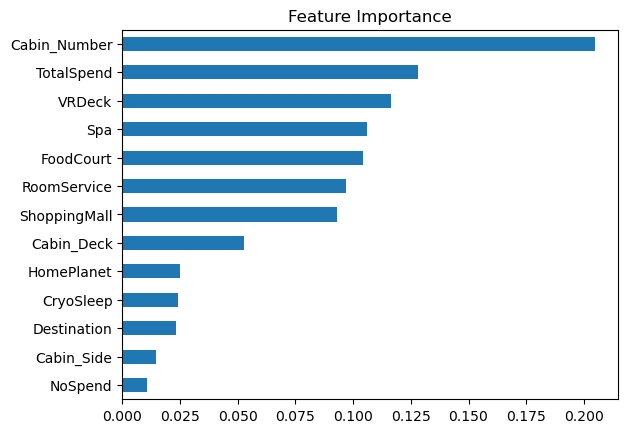

In [136]:
import matplotlib.pyplot as plt
importances = rf.feature_importances_
feat_importance = pd.Series(importances, index=features)
feat_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()
